C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


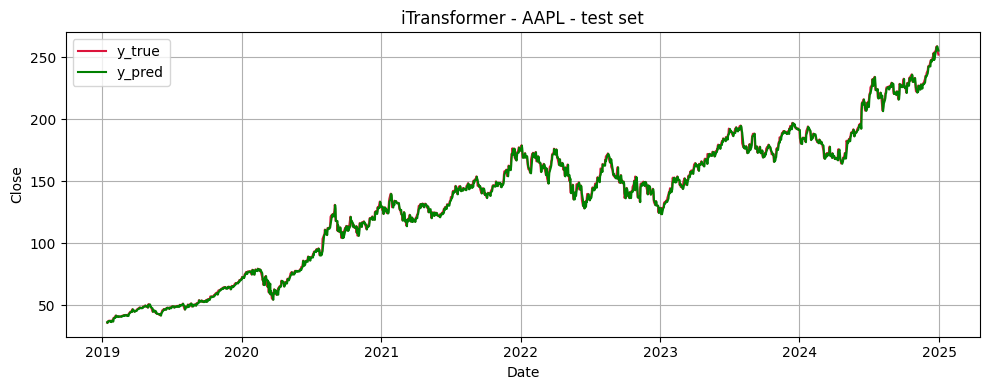

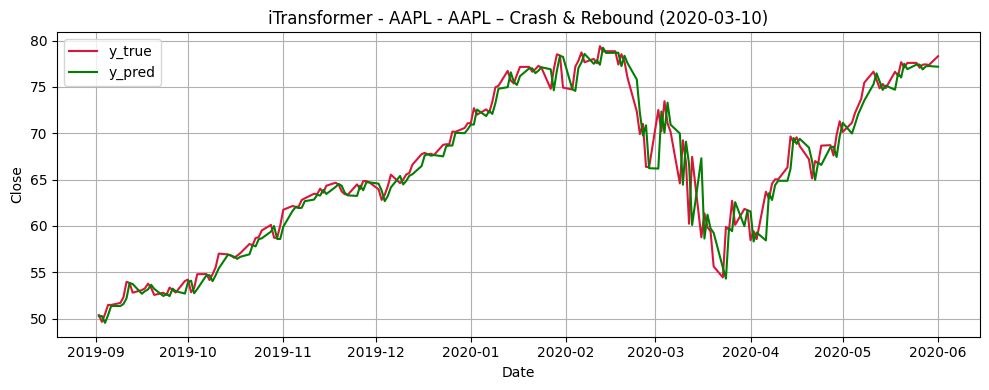

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


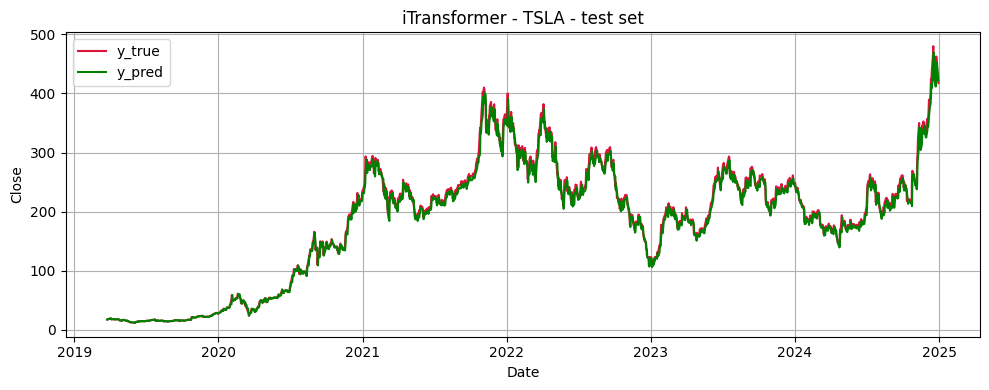

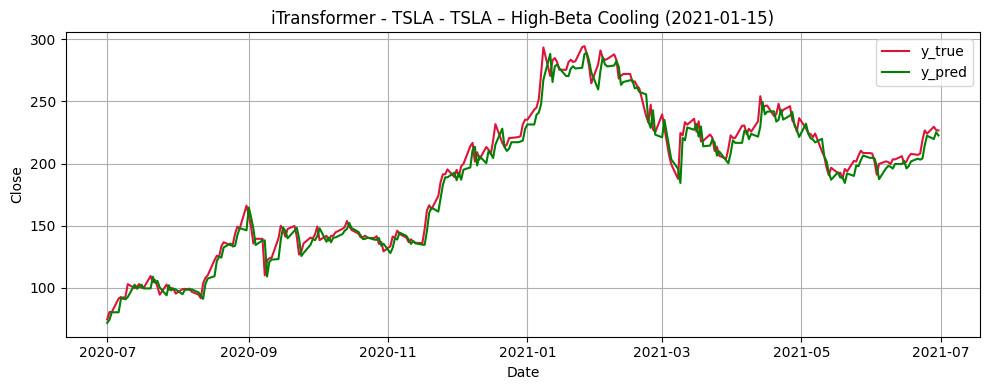

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


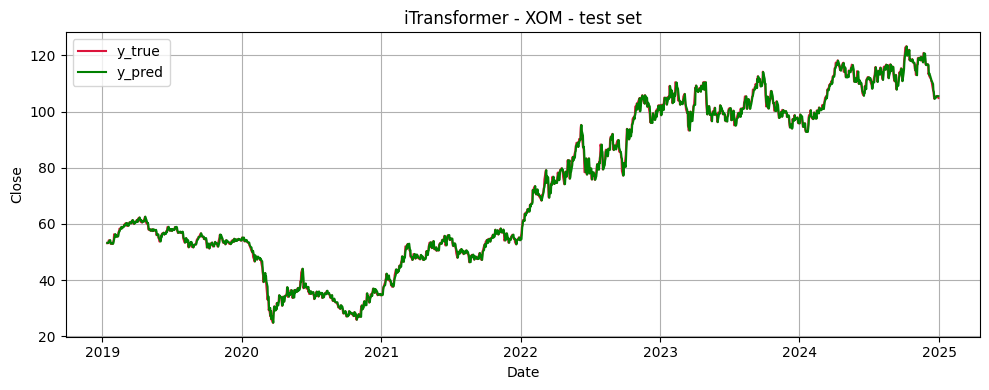

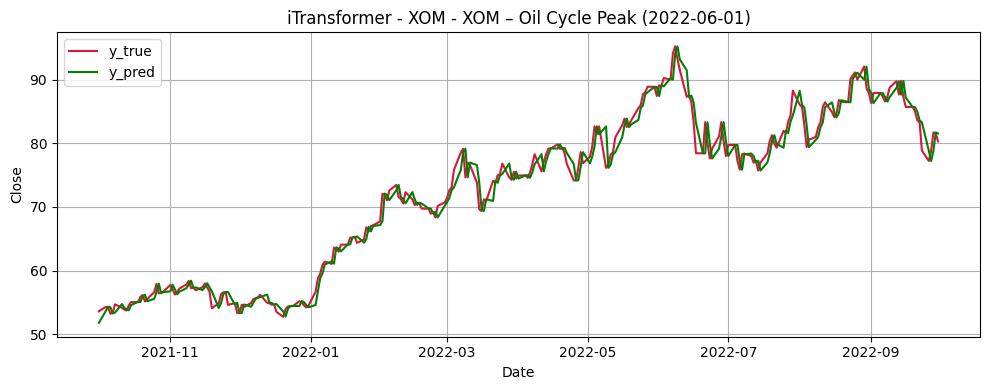

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


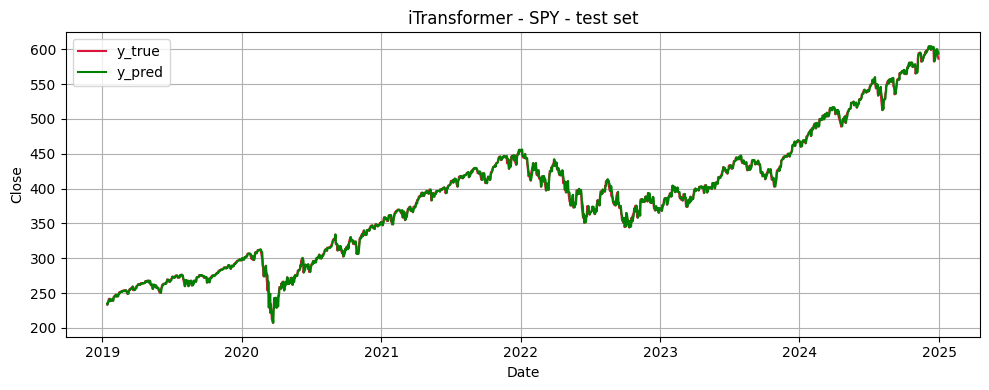

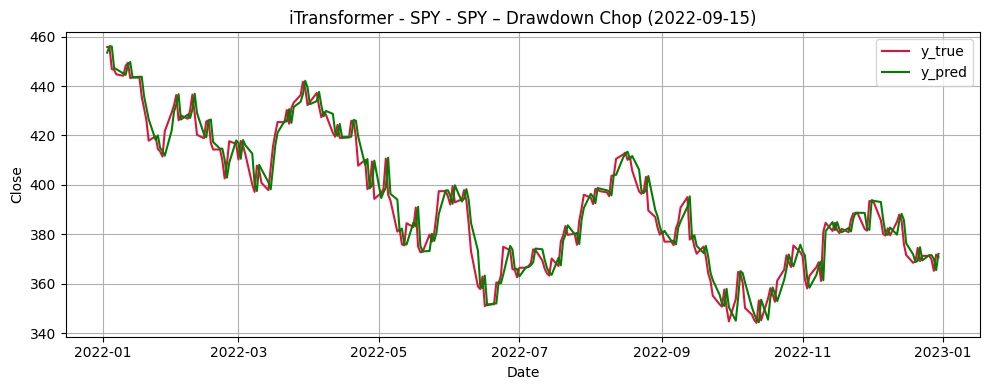

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


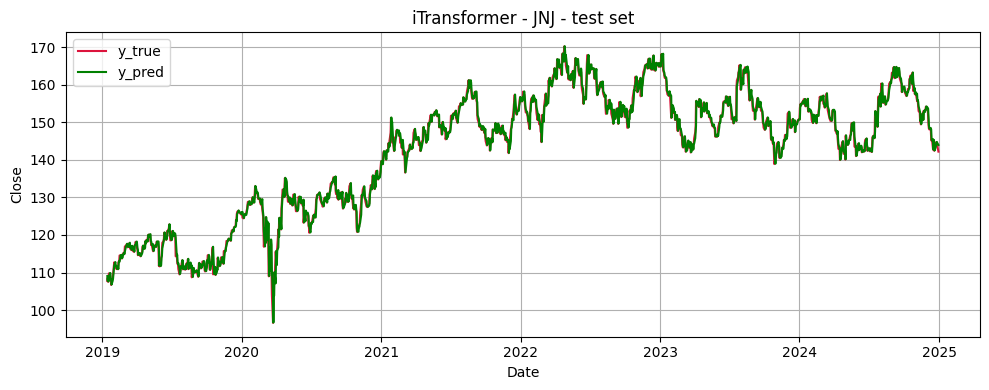

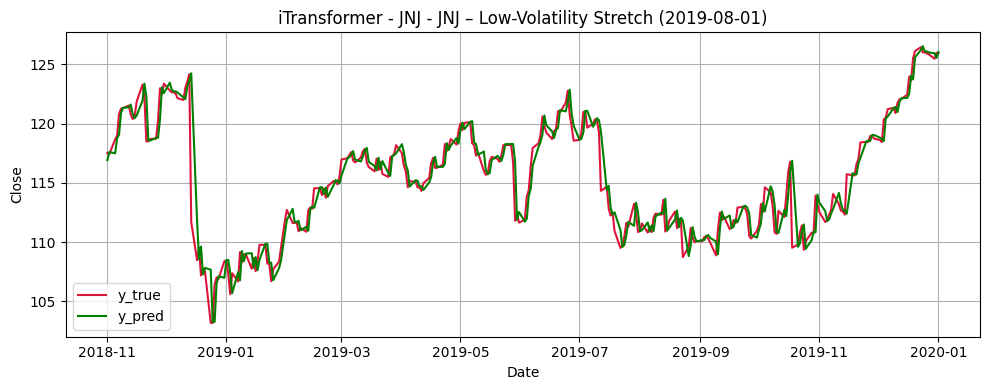

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


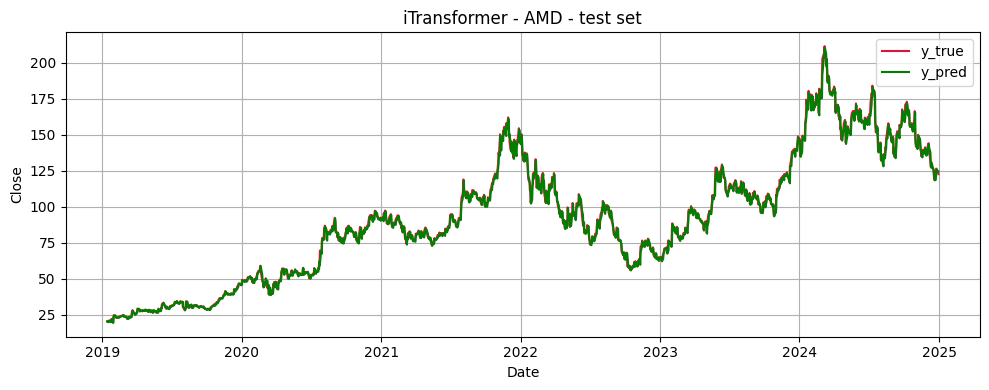

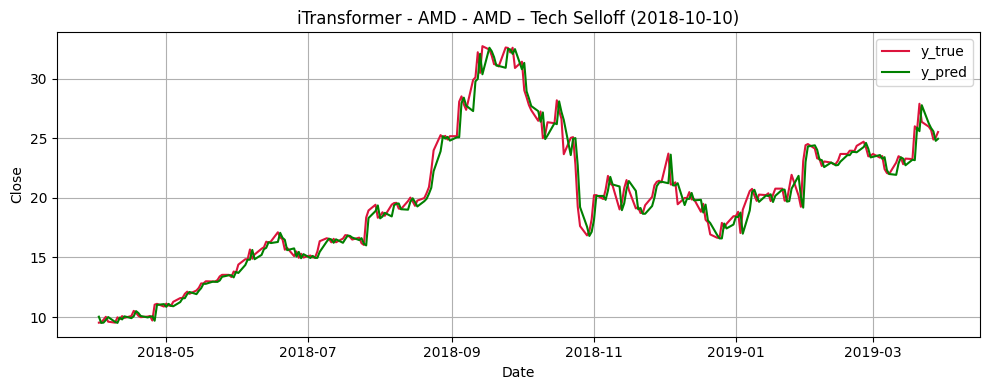

C:\Users\User\Desktop\project\project\tsfm\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


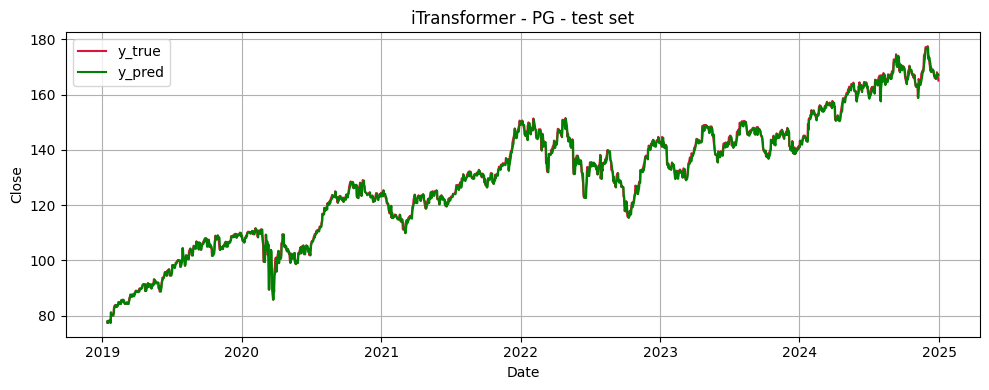

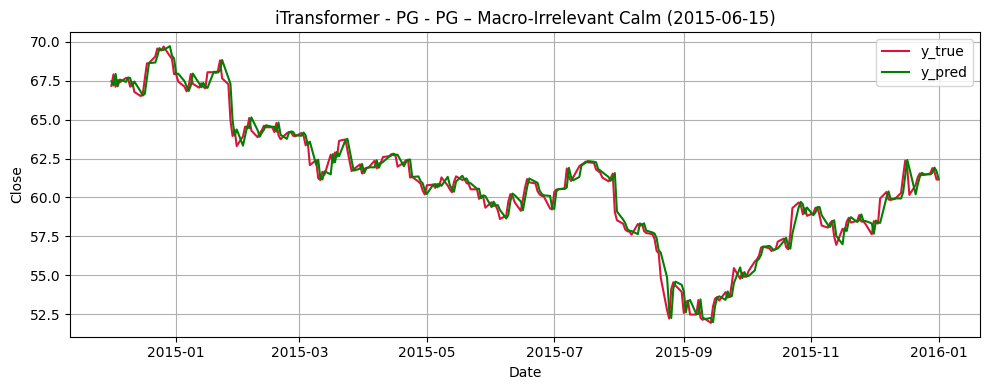

Saved per-ticker predictions & summaries to itransformer_result


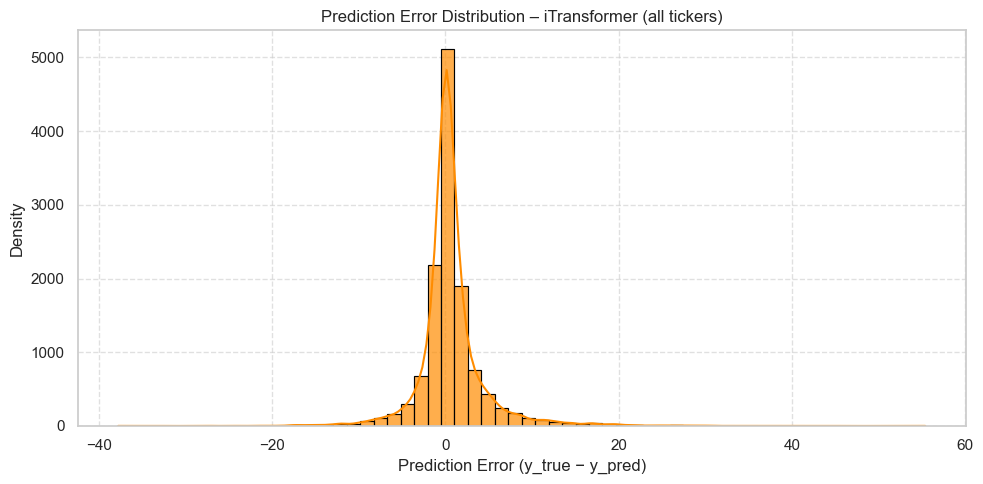


Regime matrix:
                           mae      rmse      mape  hit_rate  precision  \
regime_type                                                              
High-Volatility      4.198947  6.190451  2.792135  0.482739   0.481169   
Low-Volatility       1.081556  1.563383  0.813544  0.511576   0.520468   
Post-Trend Reversal  1.328089  1.863092  1.372356  0.504823   0.510763   
Sideways/Chop        2.926439  4.211686  0.797077  0.490675   0.523148   

                       recall        f1  
regime_type                              
High-Volatility      0.497197  0.489047  
Low-Volatility       0.534619  0.527448  
Post-Trend Reversal  0.524377  0.517481  
Sideways/Chop        0.543269  0.533019  


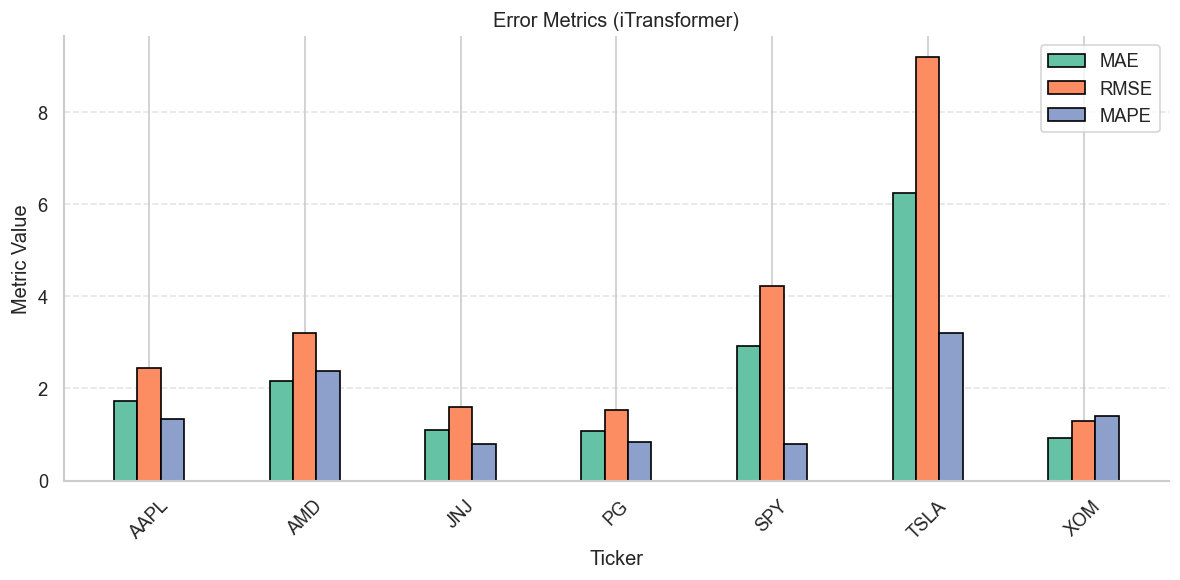

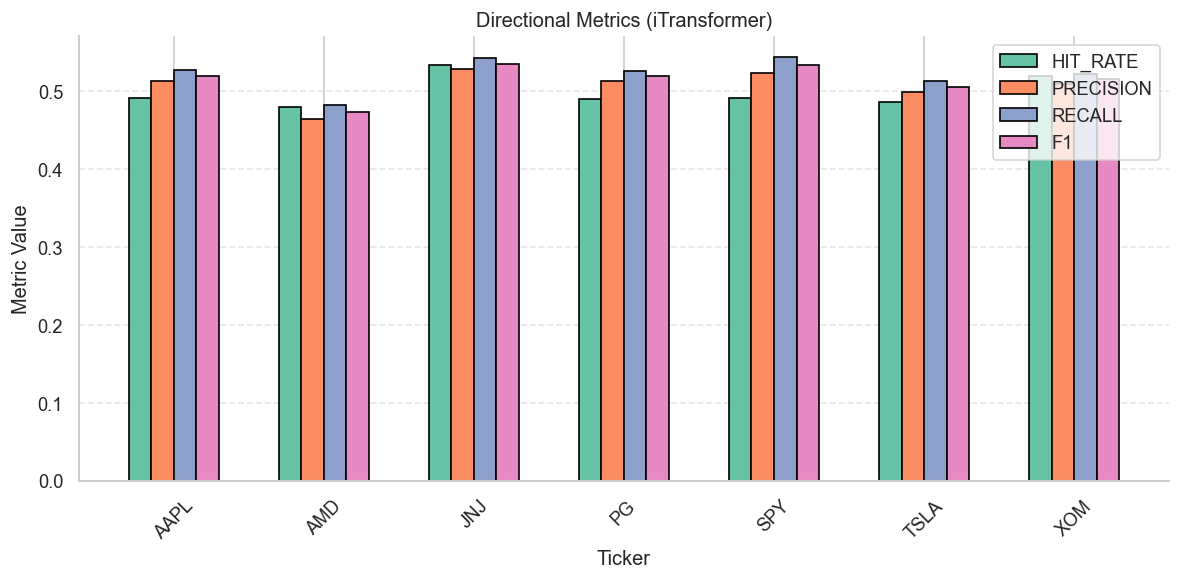

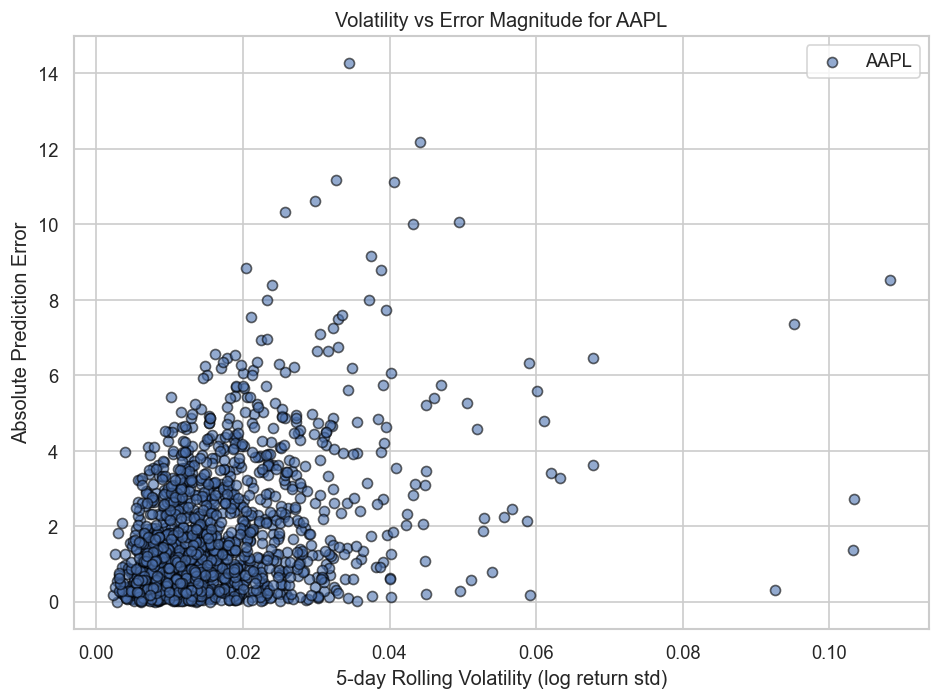

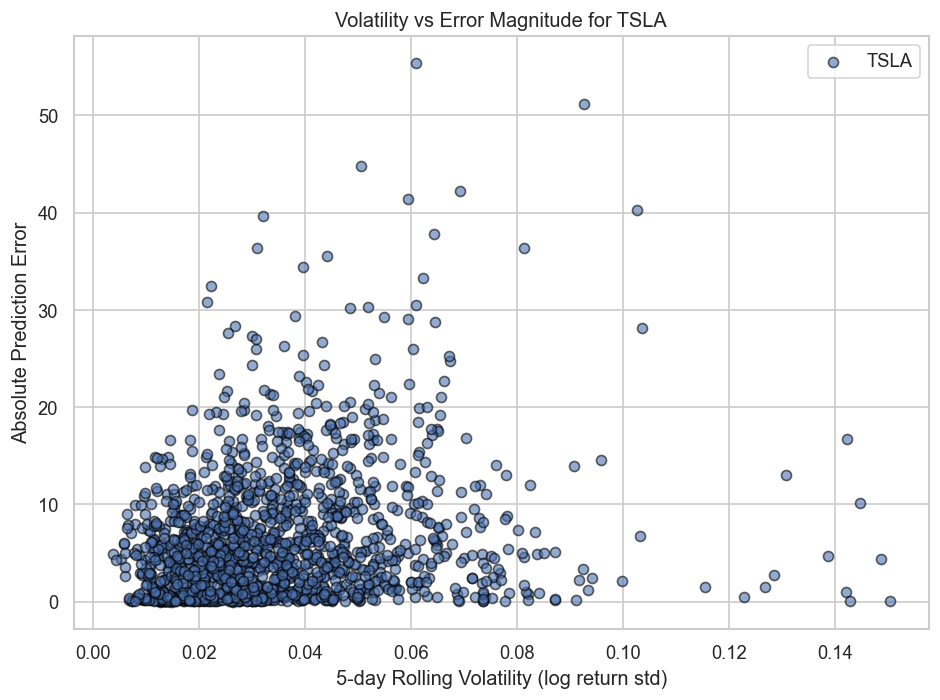

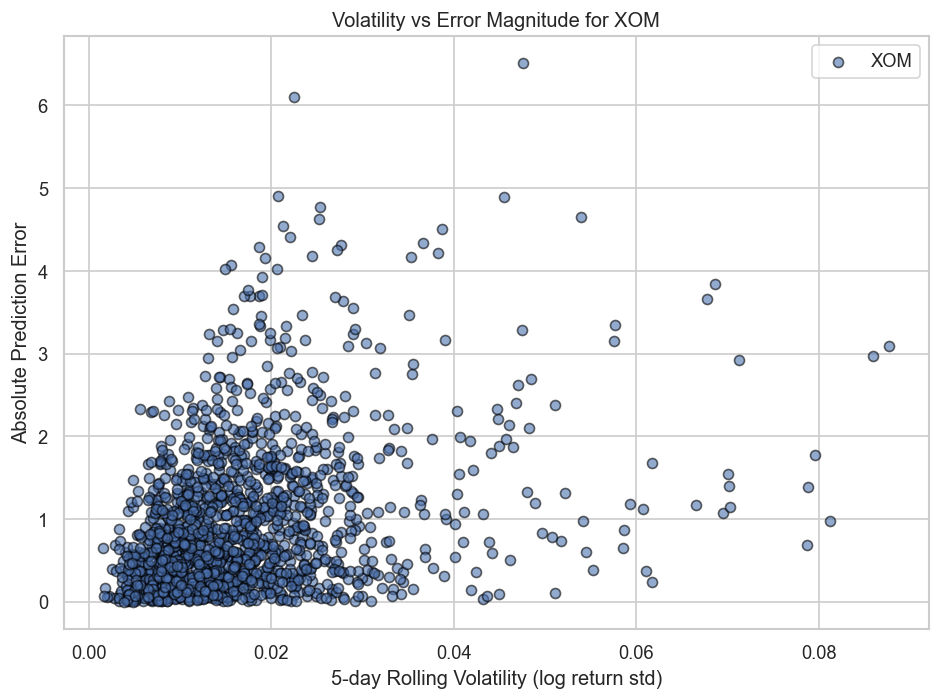

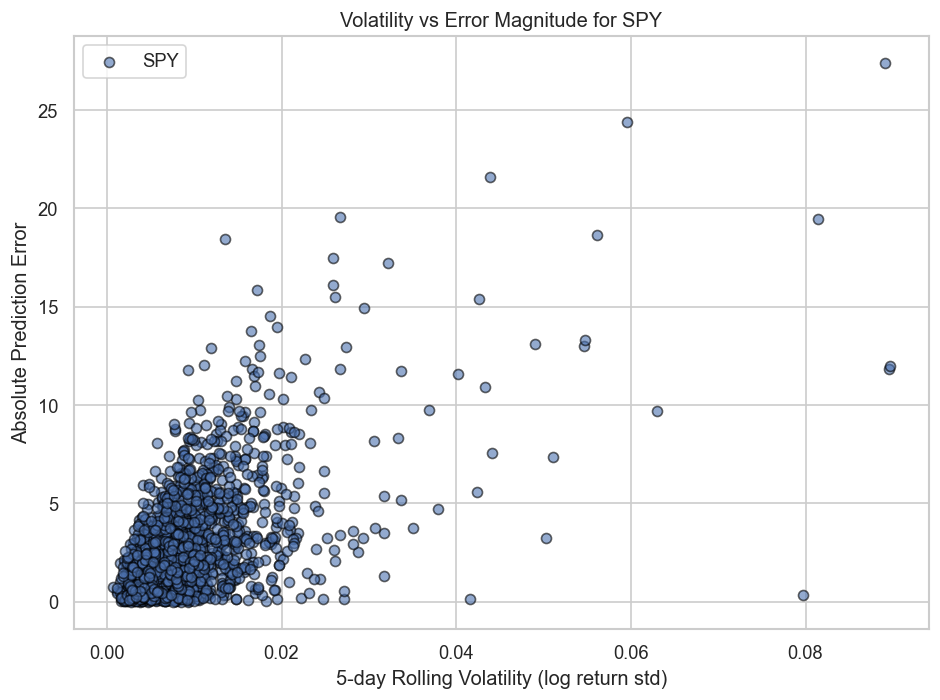

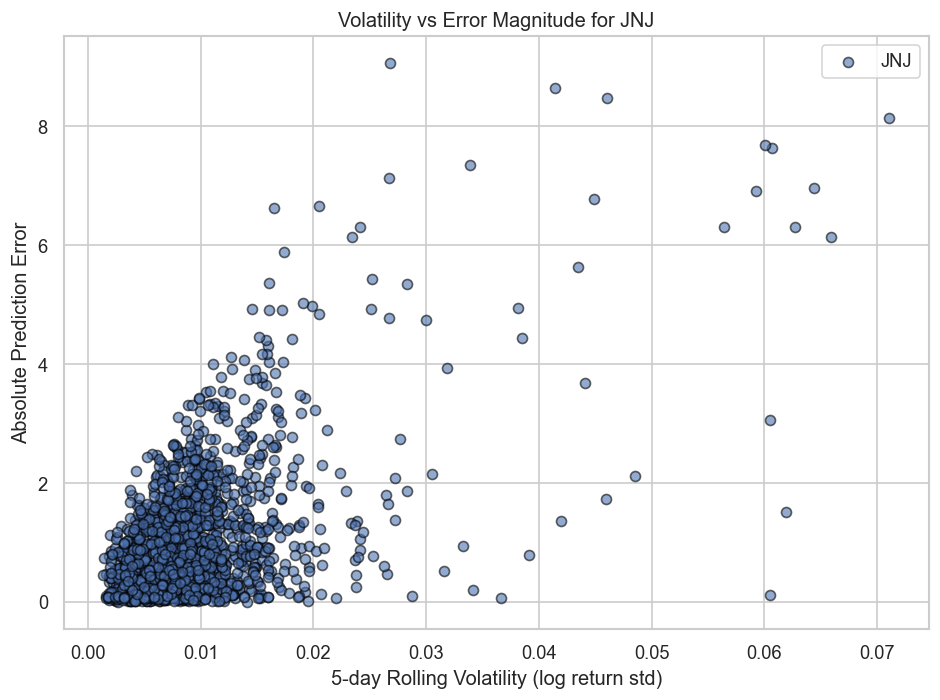

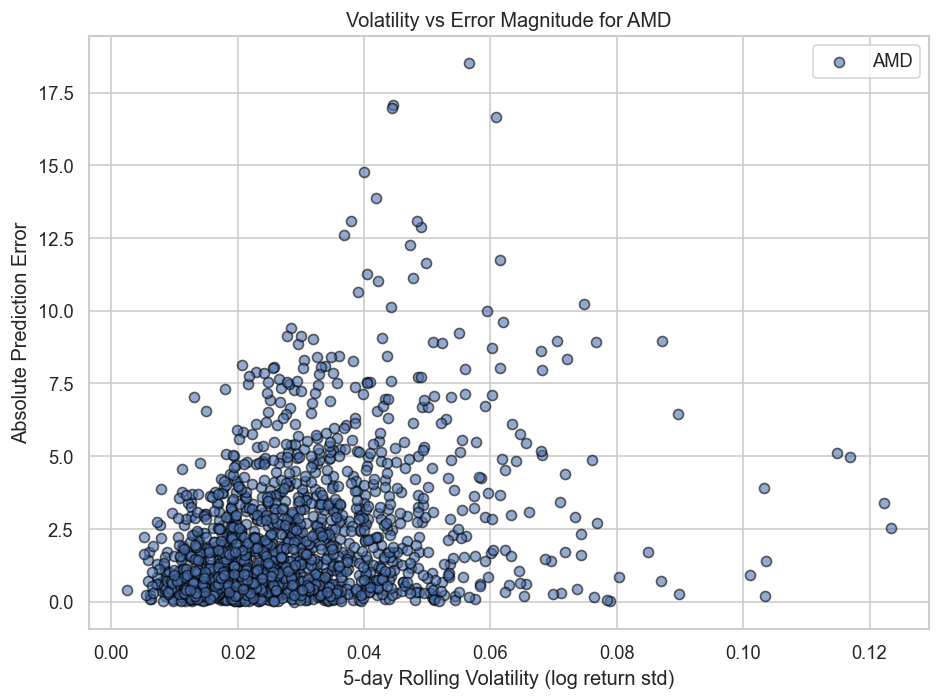

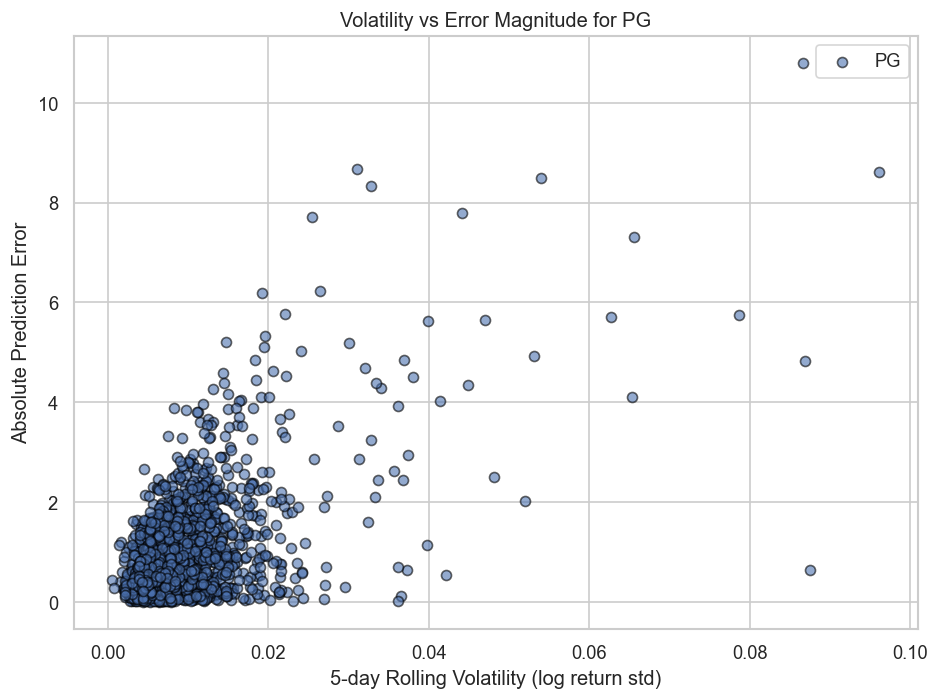


Econ metrics:
           Sharpe  cum_return  max_drawdown
ticker                                    
AAPL   -0.001116   -0.032315      1.059320
TSLA    0.018877    1.116180      1.418716
XOM     0.003489    0.106528      0.883518
SPY     0.037908    0.713565      0.394710
JNJ     0.003348    0.060370      0.695248
AMD     0.022553    1.105787      1.300091
PG      0.011200    0.216266      0.340217


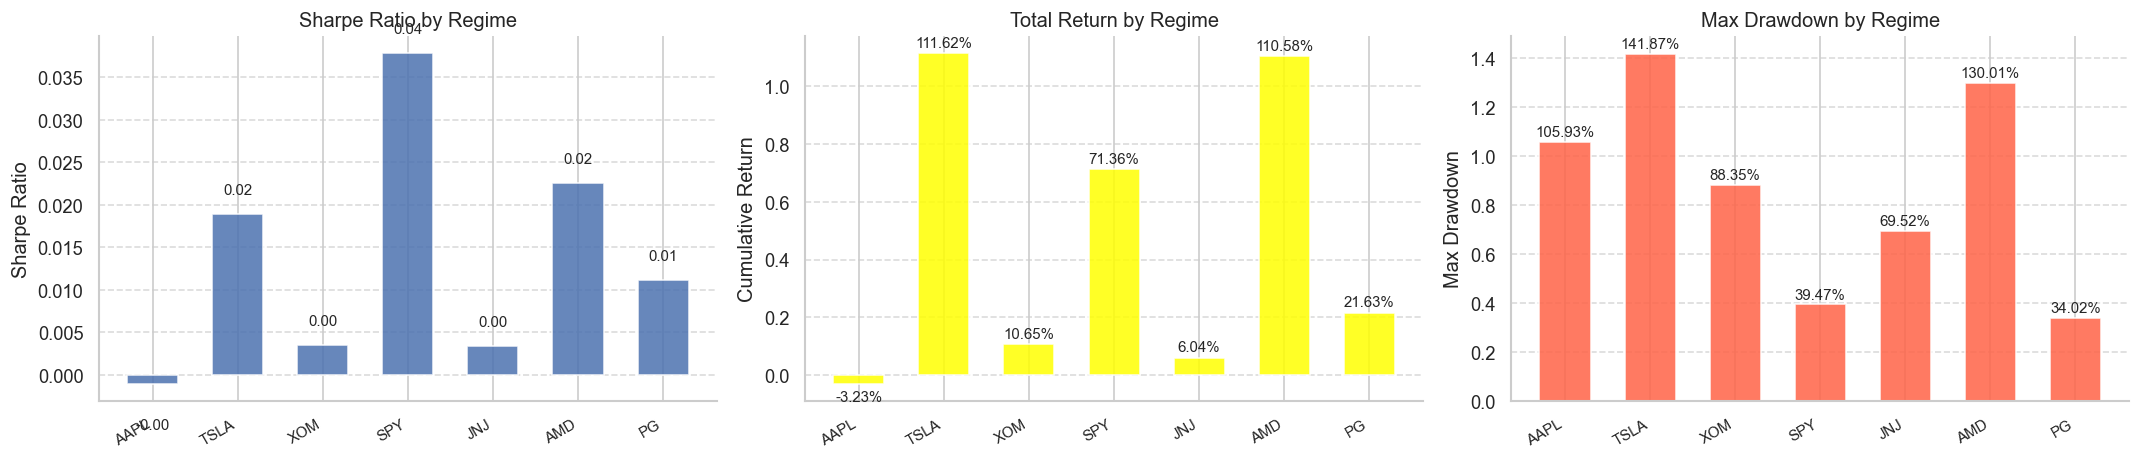

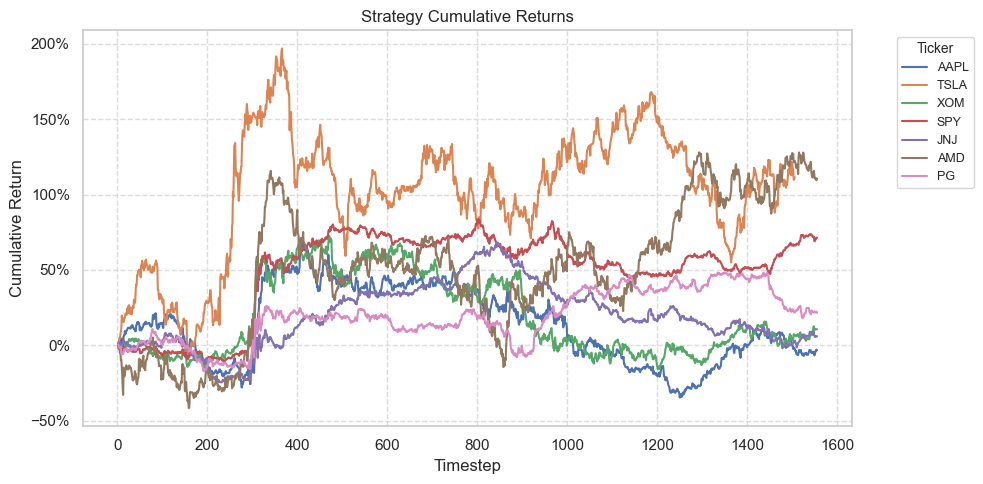

ValueError: Input contains NaN.

In [ ]:

import os, re, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------ Config ------------------
DATA_DIR = "./final_data"
OUT_DIR  = "itransformer_result"
FINALMODEL_DIR = "finalmodel"  
os.makedirs(OUT_DIR, exist_ok=True)

TICKERS = ["AAPL","TSLA","XOM","SPY","JNJ","AMD","PG"]
EVENT_TITLES = [
    "AAPL – Crash & Rebound (2020-03-10)",
    "TSLA – High-Beta Cooling (2021-01-15)",
    "XOM – Oil Cycle Peak (2022-06-01)",
    "SPY – Drawdown Chop (2022-09-15)",
    "JNJ – Low-Volatility Stretch (2019-08-01)",
    "AMD – Tech Selloff (2018-10-10)",
    "PG – Macro-Irrelevant Calm (2015-06-15)"
]
STARTS = ["2019-09-02","2020-07-01","2021-10-01","2022-01-03","2018-11-01","2018-04-02","2014-12-01"]
ENDS   = ["2020-06-01","2021-06-30","2022-09-30","2022-12-30","2020-01-01","2019-03-29","2016-01-01"]

DATE_COL = "date"
TARGET   = "close"
FEATURES = ["open","high","low","sma_20","ema_20","wma_20","tema_20","bb_upper","bb_lower"]

LOOKBACK = 256           
D_MODEL  = 128
N_HEAD   = 8
N_LAYERS = 2
DIM_FF   = 256
DROPOUT  = 0.1
EPOCHS   = 30
BATCH    = 64
LR       = 1e-3
SEED     = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REGIME_MAP = {
    "TSLA": "High-Volatility",
    "AMD": "High-Volatility",
    "SPY": "Sideways/Chop",
    "PG": "Low-Volatility",
    "JNJ": "Low-Volatility",
    "AAPL": "Post-Trend Reversal",
    "XOM": "Post-Trend Reversal"
}
EVENTS = {t: (EVENT_TITLES[i], STARTS[i], ENDS[i]) for i, t in enumerate(TICKERS)}

def slug(s: str) -> str:
    s = re.sub(r"[–—]", "-", s)
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    return s.strip("_")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(1)  # (max_len, 1, d_model)

    def forward(self, x):  # x: (seq, batch, d_model)
        L = x.size(0)
        return x + self.pe[:L, :].to(x.device)

class ITransformer(nn.Module):
    def __init__(self, n_features, d_model=D_MODEL, nhead=N_HEAD, num_layers=N_LAYERS,
                 dim_ff=DIM_FF, dropout=DROPOUT):
        super().__init__()
        self.in_proj = nn.Linear(n_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=False, activation="gelu", norm_first=True
        )
        self.pos = PositionalEncoding(d_model)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x):  # x: (batch, seq, features)
        x = self.in_proj(x)         # (batch, L, d_model)
        x = x.transpose(0,1)        # (L, batch, d_model)
        x = self.pos(x)
        h = self.encoder(x)         # (L, batch, d_model)
        last = h[-1]                # (batch, d_model)
        out = self.head(last).squeeze(-1)  # (batch,)
        return out

def make_train_windows(X_sc, r_sc, lookback, train_end):
    # target r_t uses price_{t-1}; need at least lookback + 1 history
    idx = np.arange(lookback + 1, train_end, dtype=int)
    if len(idx) == 0: return np.array([]), np.array([])
    Xw = np.stack([X_sc[i-lookback:i, :] for i in idx], axis=0)
    yw = r_sc[idx]
    return Xw, yw

def evaluate(y_true, y_pred):
    a = np.asarray(y_true, dtype=float)
    b = np.asarray(y_pred, dtype=float)

    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    rmse = np.sqrt(mean_squared_error(a, b))
    mae  = mean_absolute_error(a, b)
    denom = np.where(a == 0.0, np.nan, a)      
    mape = np.nanmean(np.abs((a - b) / denom)) * 100

    if a.size >= 2:
        true_dir = np.sign(np.diff(a)) > 0
        pred_dir = np.sign(np.diff(b)) > 0
        hit  = np.mean(true_dir == pred_dir)
        precision = precision_score(true_dir, pred_dir, zero_division=0)
        recall    = recall_score(true_dir, pred_dir, zero_division=0)
        f1        = f1_score(true_dir, pred_dir, zero_division=0)
    else:
        hit = precision = recall = f1 = np.nan

    return mae, rmse, mape, hit, precision, recall, f1

def plot_forecast(dts, y_true, y_pred, title, out_png):
    plt.figure(figsize=(10,4))
    plt.plot(dts, y_true, label="y_true", color="crimson")
    plt.plot(dts, y_pred, label="y_pred", color="green")
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Close")
    plt.legend(); plt.grid(True); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

# ------------------ One-step predictions ------------------
@torch.no_grad()
def predict_returns_to_prices(model, X_sc, r_sc, prices, indices, lookback, inv_r):
    idx = np.array(indices, dtype=int)
    idx = idx[idx >= lookback + 1]
    pred_p, true_p, keep = [], [], []
    model.eval()
    for t in idx:
        x_win = X_sc[t-lookback:t, :]
        xb = torch.tensor(x_win, dtype=torch.float32, device=device).unsqueeze(0)
        rhat_sc = model(xb).cpu().numpy().ravel()[0]
        r_hat = inv_r(np.array([rhat_sc]))[0]
        p_prev = prices[t-1]
        p_hat  = p_prev * np.exp(r_hat)
        pred_p.append(p_hat); true_p.append(prices[t]); keep.append(t)
    return np.array(pred_p), np.array(true_p), np.array(keep)

# ------------------ Train + run per ticker ------------------
def run_one_ticker(ticker):
    title, start, end = EVENTS[ticker]
    out_dir = os.path.join(OUT_DIR, ticker); os.makedirs(out_dir, exist_ok=True)

    # Load
    df = pd.read_csv(os.path.join(DATA_DIR, f"{ticker}.csv"), parse_dates=[DATE_COL])
    df.columns = [c.lower() for c in df.columns]
    df = df.sort_values(DATE_COL).set_index(DATE_COL)

    for c in [TARGET] + FEATURES:
        if c not in df.columns: raise ValueError(f"[{ticker}] Missing column: {c}")

    X_all = df[FEATURES].values.astype(float)
    y_all = df[TARGET].values.astype(float)
    dates = df.index.values
    N = len(df)

    # Returns target
    logp  = np.log(y_all)
    r_all = np.r_[0.0, np.diff(logp)]  # first is 0 for alignment

    # Splits
    train_end   = int(0.42 * N)
    test1_start = N - int(0.40 * N)
    mask_event  = (df.index >= pd.Timestamp(start)) & (df.index <= pd.Timestamp(end))

    # Scale: features MinMax (fit on train), returns Standard (fit on train)
    scaler_X = MinMaxScaler()
    X_train_sc = scaler_X.fit_transform(X_all[:train_end])
    X_all_sc   = np.vstack([X_train_sc, scaler_X.transform(X_all[train_end:])])

    scaler_r   = StandardScaler()
    r_train_sc = scaler_r.fit_transform(r_all[:train_end].reshape(-1,1)).ravel()
    r_all_sc   = scaler_r.transform(r_all.reshape(-1,1)).ravel()
    inv_r      = lambda arr: scaler_r.inverse_transform(arr.reshape(-1,1)).ravel()

    # Train windows
    Xtr, ytr = make_train_windows(X_all_sc, r_all_sc, LOOKBACK, train_end)
    if len(Xtr) == 0: raise RuntimeError(f"[{ticker}] Train too short for LOOKBACK={LOOKBACK}")

    # val split
    n_val = max(1, int(0.1 * len(Xtr)))
    X_val, y_val = Xtr[-n_val:], ytr[-n_val:]
    X_trn, y_trn = Xtr[:-n_val], ytr[:-n_val]

    # Model
    n_features = Xtr.shape[-1]
    model = ITransformer(n_features).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    def to_tensor(x): return torch.tensor(x, dtype=torch.float32, device=device)

    dl_train = DataLoader(TensorDataset(to_tensor(X_trn), to_tensor(y_trn)),
                          batch_size=min(BATCH, len(X_trn)), shuffle=True, drop_last=False)
    dl_val   = DataLoader(TensorDataset(to_tensor(X_val), to_tensor(y_val)),
                          batch_size=min(BATCH, len(X_val)), shuffle=False, drop_last=False)

    # Train with basic early-stop
    best_val, patience, PAT = float("inf"), 0, 6
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in dl_train:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        # val
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for xb, yb in dl_val:
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
            val_loss /= len(dl_val.dataset)
        if val_loss < best_val - 1e-6:
            best_val, patience = val_loss, 0
            torch.save(model.state_dict(), os.path.join(out_dir, "best_model.pt"))
        else:
            patience += 1
            if patience >= PAT: break

    model.load_state_dict(torch.load(os.path.join(out_dir, "best_model.pt"), map_location=device))
    model.eval()

    # -------- Test set (last 40%) --------
    test_indices = np.arange(test1_start, N, dtype=int)
    yhat_p, ytrue_p, idx1 = predict_returns_to_prices(model, X_all_sc, r_all_sc, y_all,
                                                      test_indices, LOOKBACK, inv_r)
    dates1 = dates[idx1]
    pd.DataFrame({"Date": dates1, "y_true": ytrue_p, "y_pred": yhat_p}).to_csv(
        os.path.join(out_dir, f"{ticker}_last_40pct_itransformer.csv"), index=False
    )
    plot_forecast(dates1, ytrue_p, yhat_p, f"iTransformer - {ticker} - test set",
                  os.path.join(out_dir, f"{ticker}_last_40pct_itransformer.png"))
    m_last = evaluate(ytrue_p, yhat_p)

    # -------- Event window --------
    event_indices = np.where(mask_event)[0]
    yhat_ev_p, ytrue_ev_p, idxev = predict_returns_to_prices(model, X_all_sc, r_all_sc, y_all,
                                                             event_indices, LOOKBACK, inv_r)
    datesev = dates[idxev]; ev_slug = slug(title)
    pd.DataFrame({"Date": datesev, "y_true": ytrue_ev_p, "y_pred": yhat_ev_p}).to_csv(
        os.path.join(out_dir, f"{ticker}_{ev_slug}_itransformer.csv"), index=False
    )
    plot_forecast(datesev, ytrue_ev_p, yhat_ev_p, f"iTransformer - {ticker} - {title}",
                  os.path.join(out_dir, f"{ticker}_{ev_slug}_itransformer.png"))
    m_event = evaluate(ytrue_ev_p, yhat_ev_p)

    return m_last, m_event

# ------------------ Run all tickers & summaries ------------------
rows_last, rows_ev = [], []
for t in TICKERS:
    m_last, m_ev = run_one_ticker(t)
    rows_last.append([t, *m_last])
    rows_ev.append([t, *m_ev])

cols = ["ticker","mae","rmse","mape","hit_rate","precision","recall","f1"]
pd.DataFrame(rows_last, columns=cols).to_csv(os.path.join(OUT_DIR, "summary_last40.csv"), index=False)
pd.DataFrame(rows_ev,   columns=cols).to_csv(os.path.join(OUT_DIR, "summary_events.csv"), index=False)

print("Saved per-ticker predictions & summaries to", OUT_DIR)



# =================================================================
#                           POST-PROCESS
# =================================================================

# 1) One big error-distribution plot (all files)
errs=[]
for t in TICKERS:
    for p in glob.glob(os.path.join(OUT_DIR, t, "*_itransformer.csv")):
        df = pd.read_csv(p)
        if {"y_true","y_pred"}.issubset(df.columns):
            e = (df["y_true"] - df["y_pred"]).dropna().values
            if e.size: errs.append(e)
if errs:
    errors = np.concatenate(errs)
    plt.figure(figsize=(10,5))
    sns.set(style="whitegrid")
    sns.histplot(errors, bins=60, kde=True, color="darkorange", edgecolor="black", alpha=0.7)
    plt.title("Prediction Error Distribution – iTransformer (all tickers)")
    plt.xlabel("Prediction Error (y_true − y_pred)"); plt.ylabel("Density")
    plt.grid(True, linestyle="--", alpha=0.6); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "error_dist_all.png"), dpi=300, bbox_inches="tight")
    plt.show()

# 2) Regime matrix (grouped means from last40)
df_last = pd.read_csv(os.path.join(OUT_DIR, "summary_last40.csv"))
df_last.set_index("ticker", inplace=True)
df_last["regime_type"] = df_last.index.map(REGIME_MAP)
grouped = df_last.groupby("regime_type").mean(numeric_only=True)
grouped.to_csv(os.path.join(OUT_DIR, "regime_matrix.csv"))
print("\nRegime matrix:\n", grouped)

# 3) Grouped barplots (last40 metrics)
def grouped_bars(df_path, metrics, title, fname):
    df = pd.read_csv(df_path).sort_values("ticker").set_index("ticker")
    tickers = df.index.tolist(); x = np.arange(len(tickers)); width = 0.15
    fig, ax = plt.subplots(figsize=(10,5), dpi=120)
    colors = sns.color_palette("Set2", len(metrics))
    for i, m in enumerate(metrics):
        ax.bar(x + i*width, df[m], width, label=m.upper(), color=colors[i], edgecolor="black")
    ax.set_title(title); ax.set_xlabel("Ticker"); ax.set_ylabel("Metric Value")
    ax.set_xticks(x + width*(len(metrics)-1)/2); ax.set_xticklabels(tickers, rotation=45)
    ax.legend(); ax.spines[['top','right']].set_visible(False); ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f"{fname}.png"), dpi=300, bbox_inches="tight"); plt.show()

grouped_bars(os.path.join(OUT_DIR,"summary_last40.csv"),
             ["mae","rmse","mape"], "Error Metrics (iTransformer)", "error_metrics_per_ticker")
grouped_bars(os.path.join(OUT_DIR,"summary_last40.csv"),
             ["hit_rate","precision","recall","f1"], "Directional Metrics (iTransformer)", "directional_metrics_per_ticker")

# 4) Rolling volatility (test) + Pearson
rows=[]
for t in TICKERS:
    p = os.path.join(OUT_DIR, t, f"{t}_last_40pct_itransformer.csv")
    if not os.path.exists(p): continue
    df = pd.read_csv(p, parse_dates=["Date"])
    df["log_return"] = np.log(df["y_true"]).diff()
    df["rolling_volatility"] = df["log_return"].rolling(5).std()
    df["abs_error"] = (df["y_true"] - df["y_pred"]).abs()
    d = df.dropna(subset=["rolling_volatility","abs_error"])
    plt.figure(figsize=(8,6), dpi=120)
    plt.scatter(d["rolling_volatility"], d["abs_error"], alpha=0.6, edgecolor="black", label=t)
    plt.title(f"Volatility vs Error Magnitude for {t}")
    plt.xlabel("5-day Rolling Volatility (log return std)"); plt.ylabel("Absolute Prediction Error")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, t, f"{t}_rolling_volatility_last40_itransformer.png"), dpi=300, bbox_inches="tight")
    plt.show()
    # Pearson (safe manual version)
    a = d["rolling_volatility"].values; b = d["abs_error"].values
    a = a - a.mean(); b = b - b.mean()
    denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum()))
    r = float((a*b).sum() / denom) if denom != 0 else np.nan
    rows.append([t, r, len(d)])
pd.DataFrame(rows, columns=["ticker","pearson_corr","n_points"]).to_csv(
    os.path.join(OUT_DIR, "vol_error_correlation_last40.csv"), index=False
)

# 5) Econ metrics (test) + barplots + cumulative
def econ_metrics(df):
    df = df.copy()
    df["log_return"] = np.log(df["y_true"]).diff()
    df["pred_log_return"] = np.log(df["y_pred"]).diff()
    df["strategy_return"] = df["pred_log_return"].shift(1) * np.sign(df["log_return"])
    df["cum_return"] = df["strategy_return"].cumsum()
    sharpe = df["strategy_return"].mean() / df["strategy_return"].std()
    cum_return = df["cum_return"].iloc[-1]
    max_dd = (df["cum_return"].cummax() - df["cum_return"]).max()
    return {"Sharpe": sharpe, "cum_return": cum_return, "max_drawdown": max_dd, "cum_series": df["cum_return"].reset_index(drop=True)}

econ_rows, series = [], {}
for t in TICKERS:
    p = os.path.join(OUT_DIR, t, f"{t}_last_40pct_itransformer.csv")
    if not os.path.exists(p): continue
    em = econ_metrics(pd.read_csv(p))
    em["ticker"] = t
    econ_rows.append(em); series[t] = em["cum_series"]

econ_df = pd.DataFrame(econ_rows).set_index("ticker")
econ_df.drop(columns=["cum_series"]).to_csv(os.path.join(OUT_DIR, "econ_metrics_last40.csv"))
print("\nEcon metrics:\n", econ_df.drop(columns=["cum_series"]))

# barplots
x = np.arange(len(econ_df)); width = 0.6
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,4), dpi=120)
b = ax1.bar(x, econ_df["Sharpe"], width, alpha=0.85)
for r in b:
    h=r.get_height()
    if not np.isnan(h): ax1.text(r.get_x()+r.get_width()/2, h+(0.002 if h>=0 else -0.004), f"{h:.2f}",
                                  ha="center", va="bottom" if h>=0 else "top", fontsize=9)
ax1.set_xticks(x); ax1.set_xticklabels(econ_df.index, rotation=30, ha="right", fontsize=9)
ax1.set_title("Sharpe Ratio by Regime"); ax1.set_ylabel("Sharpe Ratio")
ax1.grid(axis="y", linestyle="--", alpha=0.7); [ax1.spines[s].set_visible(False) for s in ["top","right"]]

b = ax2.bar(x, econ_df["cum_return"], width, alpha=0.85, color="yellow")
for r in b:
    h=r.get_height()
    if not np.isnan(h): ax2.text(r.get_x()+r.get_width()/2, h+(0.01 if h>=0 else -0.02), f"{h:.2%}",
                                  ha="center", va="bottom" if h>=0 else "top", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(econ_df.index, rotation=30, ha="right", fontsize=9)
ax2.set_title("Total Return by Regime"); ax2.set_ylabel("Cumulative Return")
ax2.grid(axis="y", linestyle="--", alpha=0.7); [ax2.spines[s].set_visible(False) for s in ["top","right"]]

b = ax3.bar(x, econ_df["max_drawdown"], width, alpha=0.85, color="tomato")
for r in b:
    h=r.get_height()
    if not np.isnan(h): ax3.text(r.get_x()+r.get_width()/2, h+0.01, f"{h:.2%}",
                                  ha="center", va="bottom", fontsize=9)
ax3.set_xticks(x); ax3.set_xticklabels(econ_df.index, rotation=30, ha="right", fontsize=9)
ax3.set_title("Max Drawdown by Regime"); ax3.set_ylabel("Max Drawdown")
ax3.grid(axis="y", linestyle="--", alpha=0.7); [ax3.spines[s].set_visible(False) for s in ["top","right"]]
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "econ_barplots_last40.png"), dpi=300, bbox_inches="tight"); plt.show()

# cumulative
plt.figure(figsize=(10,5))
for sym, ser in series.items():
    plt.plot(np.arange(len(ser)), ser.values, label=sym)
plt.title("Strategy Cumulative Returns"); plt.xlabel("Timestep"); plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.7); plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Ticker", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "strategy_cumulative_returns_last40.png"), dpi=300, bbox_inches="tight"); plt.show()

# 6) Wilcoxon + Heatmaps (FinalModel vs iTransformer) | Positive = FinalModel better
def load_final_summary():
    """
    Load FinalModel metrics for comparison.
    Uses summary_last40.csv if present; otherwise computes from per-ticker csvs.
    Cleans NaNs before metric calc.
    """
    cand = os.path.join(FINALMODEL_DIR, "summary_last40.csv")
    if os.path.exists(cand):
        df = pd.read_csv(cand)
        for c in ["mae","rmse","mape","hit_rate","precision","recall","f1"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        return df

    rows = []
    for t in TICKERS:
        # common filenames; adjust if yours differ
        p1 = os.path.join(FINALMODEL_DIR, f"{t}_final_results.csv")
        p2 = os.path.join(FINALMODEL_DIR, f"{t}.csv")
        path = p1 if os.path.exists(p1) else (p2 if os.path.exists(p2) else None)
        if path is None:
            continue

        df = pd.read_csv(path)

        # accept either y_true/y_pred or actual/pred
        if {"y_true","y_pred"}.issubset(df.columns):
            yt = pd.to_numeric(df["y_true"], errors="coerce").values
            yp = pd.to_numeric(df["y_pred"], errors="coerce").values
        elif {"actual","pred"}.issubset(df.columns):
            yt = pd.to_numeric(df["actual"], errors="coerce").values
            yp = pd.to_numeric(df["pred"], errors="coerce").values
        else:
            # try to autodetect first two numeric cols of same length
            num = df.select_dtypes(include=[np.number])
            if num.shape[1] >= 2:
                yt, yp = num.iloc[:,0].values, num.iloc[:,1].values
            else:
                continue

        mask = np.isfinite(yt) & np.isfinite(yp)
        yt, yp = yt[mask], yp[mask]

        rows.append([t, *evaluate(yt, yp)])

    return pd.DataFrame(rows, columns=["ticker","mae","rmse","mape","hit_rate","precision","recall","f1"])

df_i = pd.read_csv(os.path.join(OUT_DIR, "summary_last40.csv")).set_index("ticker")
df_f = load_final_summary().set_index("ticker")

common = df_i.index.intersection(df_f.index)
df_i, df_f = df_i.loc[common], df_f.loc[common]

metrics = ["mae","rmse","mape","hit_rate","precision","recall","f1"]
pvals = {}
for m in metrics:
    a = pd.to_numeric(df_f[m], errors="coerce")
    b = pd.to_numeric(df_i[m], errors="coerce")
    pair = pd.concat([a, b], axis=1).dropna()
    if len(pair) >= 1:
        pvals[m] = wilcoxon(pair.iloc[:,0], pair.iloc[:,1]).pvalue
    else:
        pvals[m] = np.nan

with open(os.path.join(OUT_DIR, "wilcoxon_final_vs_itransformer.txt"), "w") as f:
    f.write("Wilcoxon p-values (FinalModel vs iTransformer)\n")
    for k, v in pvals.items():
        f.write(f"{k}: {v if pd.isna(v) else f'{v:.6f}'}\n")


# Heatmaps
# Errors: improvement = iTransformer - FinalModel (positive => FinalModel better because errors lower)
err_cols = ["mae","rmse","mape"]
diff_err = df_i[err_cols] - df_f[err_cols]
plt.figure(figsize=(6,4))
sns.heatmap(diff_err, annot=True, fmt=".2f", cmap="Blues", vmin=0, linewidths=0.5,
            cbar_kws={"label": "Improvement (iTransformer − FinalModel)"})
plt.title("Error Improvement (iTransformer − FinalModel)"); plt.ylabel("Ticker")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "heatmap_error_improvement_iTransformer_minus_Final.png"), dpi=300, bbox_inches="tight"); plt.show()

# Directional: higher better → delta = FinalModel - iTransformer (positive => FinalModel better)
dir_cols = ["hit_rate","precision","recall","f1"]
diff_dir = df_f[dir_cols] - df_i[dir_cols]
plt.figure(figsize=(7,4))
sns.heatmap(diff_dir, annot=True, fmt=".3f", cmap="RdBu", center=0, linewidths=0.5)
plt.title("Directional Delta (FinalModel − iTransformer)"); plt.ylabel("Ticker")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "heatmap_directional_delta_Final_minus_iTransformer.png"), dpi=300, bbox_inches="tight"); plt.show()

print("\nAll outputs written to ./itransformer_result/")


In [ ]:
def evaluate(y_true, y_pred):

    a = np.asarray(y_true, dtype=float)
    b = np.asarray(y_pred, dtype=float)

    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    rmse = np.sqrt(mean_squared_error(a, b))
    mae  = mean_absolute_error(a, b)
    denom = np.where(a == 0.0, np.nan, a)          # avoid div/0 in MAPE
    mape = np.nanmean(np.abs((a - b) / denom)) * 100

    if a.size >= 2:
        true_dir = np.sign(np.diff(a)) > 0
        pred_dir = np.sign(np.diff(b)) > 0
        hit  = np.mean(true_dir == pred_dir)
        precision = precision_score(true_dir, pred_dir, zero_division=0)
        recall    = recall_score(true_dir, pred_dir, zero_division=0)
        f1        = f1_score(true_dir, pred_dir, zero_division=0)
    else:
        hit = precision = recall = f1 = np.nan

    return mae, rmse, mape, hit, precision, recall, f1


def load_final_summary():
    cand = os.path.join(FINALMODEL_DIR, "summary_last40.csv")
    if os.path.exists(cand):
        df = pd.read_csv(cand)
        for c in ["mae","rmse","mape","hit_rate","precision","recall","f1"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        return df

    rows = []
    for t in TICKERS:
        # common filenames; adjust if yours differ
        p1 = os.path.join(FINALMODEL_DIR, f"{t}_final_results.csv")
        p2 = os.path.join(FINALMODEL_DIR, f"{t}.csv")
        path = p1 if os.path.exists(p1) else (p2 if os.path.exists(p2) else None)
        if path is None:
            continue

        df = pd.read_csv(path)

        # accept either y_true/y_pred or actual/pred
        if {"y_true","y_pred"}.issubset(df.columns):
            yt = pd.to_numeric(df["y_true"], errors="coerce").values
            yp = pd.to_numeric(df["y_pred"], errors="coerce").values
        elif {"actual","pred"}.issubset(df.columns):
            yt = pd.to_numeric(df["actual"], errors="coerce").values
            yp = pd.to_numeric(df["pred"], errors="coerce").values
        else:
            # try to autodetect first two numeric cols of same length
            num = df.select_dtypes(include=[np.number])
            if num.shape[1] >= 2:
                yt, yp = num.iloc[:,0].values, num.iloc[:,1].values
            else:
                continue

        mask = np.isfinite(yt) & np.isfinite(yp)
        yt, yp = yt[mask], yp[mask]

        rows.append([t, *evaluate(yt, yp)])

    return pd.DataFrame(rows, columns=["ticker","mae","rmse","mape","hit_rate","precision","recall","f1"])


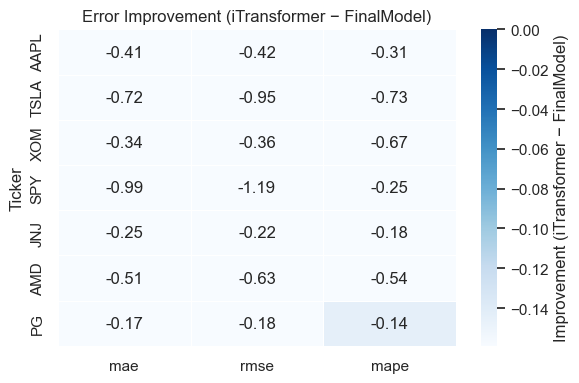

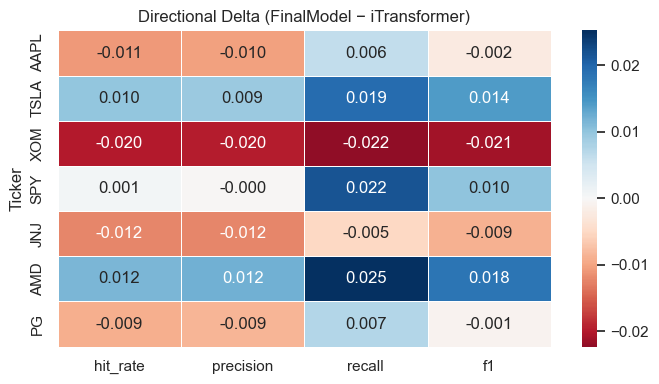


All outputs written to ./itransformer_result/


In [7]:
df_i = pd.read_csv(os.path.join(OUT_DIR, "summary_last40.csv")).set_index("ticker")
df_f = load_final_summary().set_index("ticker")

common = df_i.index.intersection(df_f.index)
df_i, df_f = df_i.loc[common], df_f.loc[common]

metrics = ["mae","rmse","mape","hit_rate","precision","recall","f1"]
pvals = {}
for m in metrics:
    a = pd.to_numeric(df_f[m], errors="coerce")
    b = pd.to_numeric(df_i[m], errors="coerce")
    pair = pd.concat([a, b], axis=1).dropna()
    if len(pair) >= 1:
        pvals[m] = wilcoxon(pair.iloc[:,0], pair.iloc[:,1]).pvalue
    else:
        pvals[m] = np.nan

with open(os.path.join(OUT_DIR, "wilcoxon_final_vs_itransformer.txt"), "w") as f:
    f.write("Wilcoxon p-values (FinalModel vs iTransformer)\n")
    for k, v in pvals.items():
        f.write(f"{k}: {v if pd.isna(v) else f'{v:.6f}'}\n")


# Heatmaps
# Errors: improvement = iTransformer - FinalModel (positive => FinalModel better because errors lower)
err_cols = ["mae","rmse","mape"]
diff_err = df_i[err_cols] - df_f[err_cols]
plt.figure(figsize=(6,4))
sns.heatmap(diff_err, annot=True, fmt=".2f", cmap="Blues", vmin=0, linewidths=0.5,
            cbar_kws={"label": "Improvement (iTransformer − FinalModel)"})
plt.title("Error Improvement (iTransformer − FinalModel)"); plt.ylabel("Ticker")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "heatmap_error_improvement_iTransformer_minus_Final.png"), dpi=300, bbox_inches="tight"); plt.show()

# Directional: higher better → delta = FinalModel - iTransformer (positive => FinalModel better)
dir_cols = ["hit_rate","precision","recall","f1"]
diff_dir = df_f[dir_cols] - df_i[dir_cols]
plt.figure(figsize=(7,4))
sns.heatmap(diff_dir, annot=True, fmt=".3f", cmap="RdBu", center=0, linewidths=0.5)
plt.title("Directional Delta (FinalModel − iTransformer)"); plt.ylabel("Ticker")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "heatmap_directional_delta_Final_minus_iTransformer.png"), dpi=300, bbox_inches="tight"); plt.show()

print("\nAll outputs written to ./itransformer_result/")
